<a href="https://colab.research.google.com/github/dhassan24/DeepLearning_For_Biology/blob/main/Chapter_2_Protein_LLM/dlfb_chapter2_proteins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning For Biology Chapter 2: Learning the Language of Proteins

## The goal of this chapter is to predict a protein's function given its amino acid sequence

REPRESENTATIONS OF PROTEINS AND PROTEIN LMs

*** Run this before saving to GitHub, to remove widget rendering issue

In [ ]:
import nbformat

path = "/content/drive/MyDrive/KGI/CS_Tutor/DeepLearning_For_Biology/DLFB_Chapter2_Proteins.ipynb"  # adjust path
nb = nbformat.read(path, as_version=4)

# Remove the bad widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, path)

In [ ]:
import nbformat
import json

# First, check what's currently in the notebook metadata
with open("/content/drive/MyDrive/KGI/CS_Tutor/DeepLearning_For_Biology/DLFB_Chapter2_Proteins.ipynb", "r") as f:
    nb = json.load(f)

print(nb["metadata"].keys())  # confirm "widgets" is there

dict_keys(['colab', 'kernelspec', 'language_info'])


In [ ]:
nb["metadata"].pop("widgets", None)

with open("/content/your_notebook.ipynb", "w") as f:
    json.dump(nb, f)

print("Done — widgets removed")

Done — widgets removed


SETUP:

In [ ]:
#clone the repository that contains the dlfb library:

%cd /content
!rm -rf ./dlfb-clone/
!git clone "https://github.com/deep-learning-for-biology/dlfb.git" dlfb-clone --branch main
%cd dlfb-clone

/content
Cloning into 'dlfb-clone'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 129 (delta 23), reused 115 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 63.15 KiB | 1.13 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/dlfb-clone


In [ ]:
#Install the required dependencies, once the library is cloned:

%%bash
curl -LsSf https://astral.sh/uv/install.sh | sh && \
export PATH="/root/.local/bin:${PATH}" && \
uv pip compile ./requirements/{base,dlfb,proteins,gpu}.txt \
  --color never \
  --constraint ./requirements/constraints.txt | \
uv pip install -r - --system

installing to /usr/local/bin
  uv
  uvx
everything's installed!


downloading uv 0.10.12 x86_64-unknown-linux-gnu
no checksums to verify
Resolved 146 packages in 3.84s
Using Python 3.12.12 environment at: /usr
Resolved 146 packages in 1.16s
Prepared 67 packages in 23.89s
Uninstalled 50 packages in 4.07s
Installed 68 packages in 1.18s
 - absl-py==1.4.0
 + absl-py==2.4.0
 + adjusttext==1.3.0
 - attrs==25.4.0
 + attrs==26.1.0
 + biopython==1.85
 - cachetools==6.2.6
 + cachetools==7.0.5
 - certifi==2026.2.25
 + certifi==2022.12.7
 - charset-normalizer==3.4.6
 + charset-normalizer==2.1.1
 + chex==0.1.90
 - click==8.3.1
 + click==8.1.8
 - cryptography==43.0.3
 + cryptography==46.0.5
 - datasets==4.0.0
 + datasets==2.19.1
 + dlfb==0.1.1 (from file:///content/dlfb-clone)
 - filelock==3.25.2
 + filelock==3.20.0
 - flax==0.11.2
 + flax==0.10.4
 - fsspec==2025.3.0
 + fsspec==2024.3.1
 - google-auth==2.47.0
 + google-auth==2.49.1
 - google-cloud-storage==3.9.0
 + google-cloud-storage==3.0.0
 - huggingface-hub==1.7.1
 + huggingface-hub==0.36.0
 - idna==3.11
 + id

In [ ]:
#Provide the datasets that we need to access, download the necessary datasets

# NOTE: exclude models with '--no-models' flag
!dlfb-provision --chapter proteins

Files Downloaded: 100% 22/22 [00:08<00:00,  2.47file/s]


In [ ]:
#IMport the dlfb package. The loading can sometimes be finicky; if you encounter
#issues then restart the runtime. You can re-run the load step without repeating everything

# Toggle JAX_DISABLE_JIT to True for easier debugging
%env JAX_DISABLE_JIT=False

try:
  import dlfb
except ImportError as exc:
  # NOTE: Packages installed in editable mode are not immediately
  #       recognized by Colab (https://stackoverflow.com/a/63312333).
  import site
  site.main()
  import dlfb

from dlfb.utils.display import display

env: JAX_DISABLE_JIT=False


In [ ]:
import py3Dmol
import requests

def fetch_protein_structure(pdb_id: str) -> str:
  """Grab a PDB protein structure from the RCSB Protein Data Bank."""
  url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
  response = requests.get(url)
  return response.text


# The Protein Data Bank (PDB) is the main database of protein structures.
# Each structure has a unique 4-character PDB ID. Below are a few examples.
protein_to_pdb = {
  "insulin": "3I40",  # Human insulin – regulates glucose uptake.
  "collagen": "1BKV",  # Human collagen – provides structural support.
  "proteasome": "1YAR",  # Archaebacterial proteasome – degrades proteins.
}

In [ ]:
protein = "insulin"  # @param ["insulin", "collagen", "proteasome"]
pdb_structure = fetch_protein_structure(pdb_id=protein_to_pdb[protein])

pdbview = py3Dmol.view(width=400, height=300)
pdbview.addModel(pdb_structure, "pdb")
pdbview.setStyle({"cartoon": {"color": "spectrum"}})
pdbview.zoomTo()
pdbview.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Numerical Representation of a Protein

In [ ]:
# Precursor insulin protein sequence (processed into two protein chains).
insulin_sequence = (
  "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG"
  "GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"
)

print(f'Lenght of the insuling protein precursor: {len(insulin_sequence)}')

Lenght of the insuling protein precursor: 110


We might want to conver a protein sequence into numerical form for ML input, using one-hot encoding.

Idea: There are 20 amino acids, each amino acid is represented by a binary vector of length 20, where only one posotion is 1 (for amino acid identity) and the other positions are 0. A protein sequence is then converted into a sequence of these on-hot vecotrs (one for each AA).

In [ ]:
from dlfb.utils.display import print_short_dict

# fmt: off
amino_acids = [
  "R", "H", "K", "D", "E", "S", "T", "N", "Q", "G", "P", "C", "A", "V", "I",
  "L", "M", "F", "Y", "W",
]
# fmt: on

amino_acid_to_index = {
    amino_acid: index for index, amino_acid in enumerate(amino_acids)
}

print_short_dict(amino_acid_to_index)

{'R': 0, 'H': 1, 'K': 2, 'D': 3, 'E': 4, 'S': 5, 'T': 6, 'N': 7, 'Q': 8, 'G': 9}
…(+10 more entries)


In [ ]:
#Given a protein sequence, we can convert it to a sequence of integers:

tiny_protein = ["M", "A", "L", "W", "M"]

tiny_protein_indices = [amino_acid_to_index[amino_acid] for amino_acid in tiny_protein]

tiny_protein_indices

[16, 12, 15, 19, 16]

In [ ]:
import pandas as pd

In [ ]:
import jax

one_hot_encoded_sequence = jax.nn.one_hot(
    x = tiny_protein_indices, num_classes=len(amino_acids)
)

print(f'The one hot encoded matrix: {one_hot_encoded_sequence} and the dimension:')

The one hot encoded matrix: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]] and the dimension:


[Text(0.5, 146.32222222222222, 'Amino Acid Index'),
 Text(50.722222222222214, 0.5, 'Protine Sequence')]

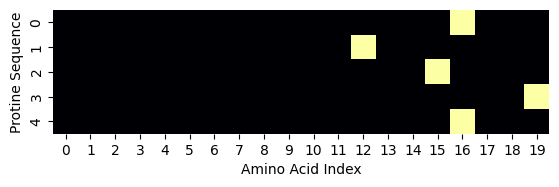

In [ ]:
import seaborn as sns

fig = sns.heatmap(
    one_hot_encoded_sequence, square = True, cbar = False, cmap = "inferno"
)

fig.set(xlabel = "Amino Acid Index", ylabel = "Protine Sequence")

Now e ware going to learn embeddings of amino acids (dense vector representations that encode much more biological meaning about each amino acid). We will use a pretrained protein language model called ESM2, which requires using PyTorch instead of JAX/Flax.

In [ ]:
#!pip install --upgrade transformers huggingface_hub
# I had to run this to get the transformers package, then restarted my session

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.1.8
    Uninstalling click-8.1.8:
      Successfully uninstalled click-8.1.8
  Attempting uninstall: typer
    Found existing installation: typer 0.7.0
    Uninstalling typer-0.7.0:
      Successfully uninstalled typer-0.7.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalled huggingface-hub-0.36.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's depend

In [ ]:
from transformers import AutoTokenizer, EsmModel

# Model checkpoint name taken from this GitHub README:
# https://github.com/facebookresearch/esm#available-models-and-datasets-
model_checkpoint = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Now check the model's token-to-index mapping:

vocab_to_index = tokenizer.get_vocab()
print_short_dict(vocab_to_index)

NameError: name 'print_short_dict' is not defined

This is like our manual amino acid indexing but this includes special tokens like <unk> for unknown residues, <eos> for end of sequence and rarer amino acids like U and O

Use the ESM2 tokenizer to encode our small protein sequence:

In [ ]:
tokenized_tiny_protein = tokenizer("MALWM")["input_ids"]
tokenized_tiny_protein

[0, 20, 5, 4, 22, 20, 2]

In [ ]:
#Can drop special start and eos tokens from start and end:
tokenized_tiny_protein[1:-1]

[20, 5, 4, 22, 20]

In [ ]:
#Now extract the learned token embeddings from the model using model.get_input_embeddings():

token_embeddings = model.get_input_embeddings().weight.detach().numpy()
token_embeddings.shape

(33, 1280)

Each of the 33 possible tokens is embedded into a 1280-dimensional space. We can use dim reduction methods like t-SNE or UMAP to project embeddings down to 2 dimensions. Allows for interpretation of how model organized different tokens.

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE

tsne = TSNE(n_components = 2, random_state = 42)
embeddings_tsne = tsne.fit_transform(token_embeddings)
embeddings_tsne_df = pd.DataFrame(
    embeddings_tsne, columns = ["first_dim", "second_dim"]
)

embeddings_tsne_df.shape

(33, 2)

In [ ]:
embeddings_tsne

array([[ -8.645726, -18.630709],
       [ -9.379321, -18.638035],
       [ -8.83415 , -18.510551],
       [ -9.364463, -18.585249],
       [ -9.064801, -17.683933],
       [ -8.903339, -17.830853],
       [ -8.731593, -17.801653],
       [ -9.04495 , -17.823654],
       [ -8.852939, -17.81797 ],
       [ -8.772124, -17.81702 ],
       [ -8.848232, -17.652971],
       [ -8.802637, -17.823242],
       [ -9.128415, -17.718575],
       [ -8.625329, -17.759396],
       [ -8.660166, -17.784897],
       [ -8.793895, -17.72259 ],
       [ -8.902323, -17.64599 ],
       [ -8.757848, -17.6152  ],
       [ -9.122639, -17.486528],
       [ -9.098574, -17.455584],
       [ -9.210955, -17.630465],
       [ -8.968455, -17.461891],
       [ -9.196412, -17.337923],
       [ -9.17536 , -17.539927],
       [ -9.901956, -17.84404 ],
       [ -9.571548, -18.123455],
       [ -9.689826, -18.078201],
       [ -9.313757, -18.07037 ],
       [ -8.991037, -17.8621  ],
       [ -8.999762, -17.909761],
       [ -

In [ ]:
embeddings_tsne_df.head(5)

,first_dim,second_dim
0,-8.645726,-18.630709
1,-9.379321,-18.638035
2,-8.834150,-18.510551
3,-9.364463,-18.585249
4,-9.064801,-17.683933


33 rows and 2 columns mean that the 33 tokens have been projected int oa 2D space

Text(0, 0.5, 'Second Dimension')

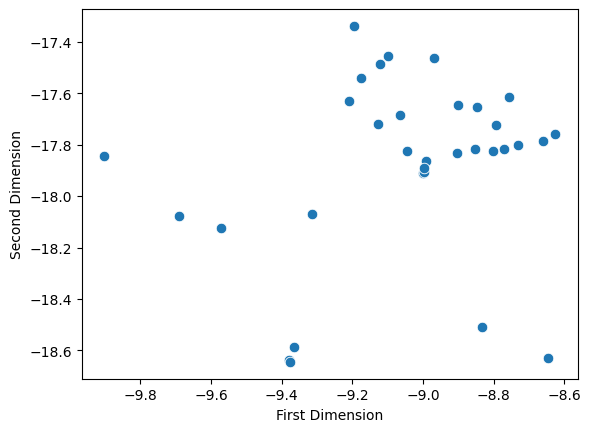

In [ ]:
import seaborn as sns

fig = sns.scatterplot(
    data = embeddings_tsne_df, x = "first_dim", y = "second_dim", s = 58
)
fig.set_xlabel("First Dimension")
fig.set_ylabel("Second Dimension")

Sanity-check whether similar types of tokens cluster in 2D embedding space. Label each token using known AA properties and replot t-SNE projection

In [ ]:
from adjustText import adjust_text

embeddings_tsne_df["token"] = list(vocab_to_index.keys())

token_annotation = {
  "hydrophobic": ["A", "F", "I", "L", "M", "V", "W", "Y"],
  "polar uncharged": ["N", "Q", "S", "T"],
  "negatively charged": ["D", "E"],
  "positively charged": ["H", "K", "R"],
  "special amino acid": ["B", "C", "G", "O", "P", "U", "X", "Z"],
  "special token": [
    "-",
    ".",
    "<cls>",
    "<eos>",
    "<mask>",
    "<null_1>",
    "<pad>",
    "<unk>",
  ],
}

In [ ]:
token_annotation

{'hydrophobic': ['A', 'F', 'I', 'L', 'M', 'V', 'W', 'Y'],
 'polar uncharged': ['N', 'Q', 'S', 'T'],
 'negatively charged': ['D', 'E'],
 'positively charged': ['H', 'K', 'R'],
 'special amino acid': ['B', 'C', 'G', 'O', 'P', 'U', 'X', 'Z'],
 'special token': ['-',
  '.',
  '<cls>',
  '<eos>',
  '<mask>',
  '<null_1>',
  '<pad>',
  '<unk>']}

In [ ]:
embeddings_tsne_df

,first_dim,second_dim,token
0,-8.645726,-18.630709,<cls>
1,-9.379321,-18.638035,<pad>
2,-8.834150,-18.510551,<eos>
3,-9.364463,-18.585249,<unk>
4,-9.064801,-17.683933,L
5,-8.903339,-17.830853,A
6,-8.731593,-17.801653,G
7,-9.044950,-17.823654,V
8,-8.852939,-17.817970,S
9,-8.772124,-17.817020,E


In [ ]:
embeddings_tsne_df["label"] = embeddings_tsne_df["token"].map(
    {t: label for label, tokens in token_annotation.items() for t in tokens}
)

In [ ]:
embeddings_tsne_df.head()

,first_dim,second_dim,token,label
0,-8.645726,-18.630709,<cls>,special token
1,-9.379321,-18.638035,<pad>,special token
2,-8.834150,-18.510551,<eos>,special token
3,-9.364463,-18.585249,<unk>,special token
4,-9.064801,-17.683933,L,hydrophobic


([Text(-8.620776531196409, -18.5879122870309, '<cls>'),
  Text(-9.219094819599583, -18.598471777779714, '<pad>'),
  Text(-8.74726699533001, -18.467755045209614, '<eos>'),
  Text(-9.326958140250175, -18.499656132289342, '<unk>'),
  Text(-9.047070648785562, -17.652808598109655, 'L'),
  Text(-8.890512856456542, -17.76860318865095, 'A'),
  Text(-8.699387909904603, -17.743391581944056, 'G'),
  Text(-9.027325135277163, -17.776967184884207, 'V'),
  Text(-8.845936086870008, -17.71806975773403, 'S'),
  Text(-8.754075209940634, -17.758661678859163, 'E'),
  Text(-8.827581997744499, -17.62184660775321, 'R'),
  Text(-8.808236486681047, -17.767994335719518, 'T'),
  Text(-9.119355177110242, -17.691340446472168, 'I'),
  Text(-8.595955023842475, -17.70881802695138, 'D'),
  Text(-8.64376008472135, -17.73928873879569, 'P'),
  Text(-8.771386502635094, -17.664230755397252, 'K'),
  Text(-8.883595597743989, -17.60359409877232, 'Q'),
  Text(-8.73319840440827, -17.58018480028425, 'N'),
  Text(-9.10542121058510

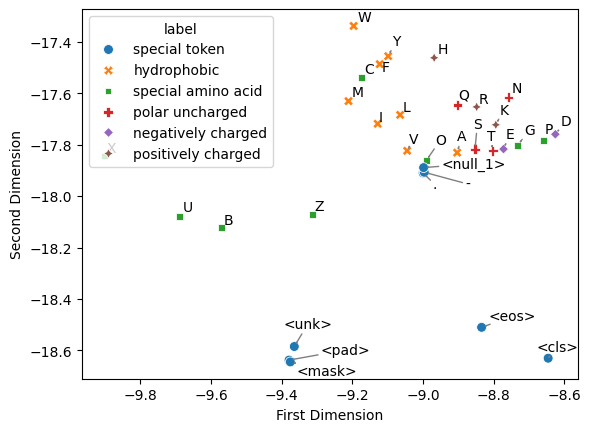

In [ ]:
fig = sns.scatterplot(
    data = embeddings_tsne_df,
    x = "first_dim",
    y = "second_dim",
    hue = "label",
    style = "label",
    s = 50
)

fig.set_xlabel("First Dimension")
fig.set_ylabel("Second Dimension")

texts = [
    fig.text(point["first_dim"], point["second_dim"], point["token"])
    for _, point in embeddings_tsne_df.iterrows()
]

adjust_text(
    texts, expand = (1.5, 1.5), arrowprops = dict(arrowstyle = "->", color = "grey")
)

Tokens with similar biochemical properties tend to cluster together (like hydrophobic amino acids).

## THE ESM2 PROTEIN LANGUAGE MODEL:

### ESM2 is a masked language model (MLM) which means it was trained by repeatedly masking a ranodm subset of AAs in each protein sequence and asking the model to predict them. In ESM2, a randomly selected 15% of the amino acids in each sequence were masked during training.

In [ ]:
# EXAMPLE: TRY MAKINSG ONE AMINO ACID IN THE INSULING PROTEIN SEQUENCE AND SEE IF THE MODEL CAN PREDICT IT

insulin_sequence = (
  "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG"
  "GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"
)

#Going to mask the L in the 29th amino acid position
masked_insulin_sequence = (
    "MALWMRLLPLLALLALWGPDPAAAFVNQH<mask>CGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG"
  "GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"
)

#Tokenize the masked insulin sequence.
masked_inputs = tokenizer(masked_insulin_sequence)["input_ids"]

#Check that we have a <mask> token in the place we expect it. Tokenizer adds <cls> at the start
#so <mask> will be at position 30 now instead of 29

assert masked_inputs[30] == vocab_to_index["<mask>"]

The <mask> token tells the model to predict the amino acid at that position. To do this, we load the full language model, EsmForMaskedLM, which includes the language prediciton head

In [ ]:
#Load th EsmForMaskedLM model:

from transformers import EsmForMaskedLM

# Model checkpoint name taken from this GitHub README:
# https://github.com/facebookresearch/esm#available-models-and-datasets-
model_checkpoint = "facebook/esm2_t30_150M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
masked_lm_model = EsmForMaskedLM.from_pretrained(model_checkpoint)

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#Run the model to get predictions for the masked token (which should be L)

import matplotlib.pyplot as plt
import jax

model_outputs = masked_lm_model(
    **tokenizer(text = masked_insulin_sequence, return_tensors= "pt")
)

model_preds = model_outputs.logits

#Index into predictions at the <mask> position

mask_preds = model_preds[0, 30].detach().numpy()

#Apply softmax to conver the model's predicted logits to probabilities:

mask_probs = jax.nn.softmax(mask_preds)

In [ ]:
mask_probs

Array([2.7657064e-08, 6.7935510e-12, 1.7983336e-09, 6.9586628e-12,
       9.4958466e-01, 8.9680200e-04, 7.4796357e-05, 6.4928886e-03,
       5.1447708e-04, 2.9093291e-05, 8.5564842e-04, 6.5913919e-04,
       5.1001823e-03, 1.5708580e-05, 6.3465495e-04, 1.0362651e-04,
       5.0258351e-04, 9.2020389e-05, 2.1843903e-02, 4.9074730e-03,
       6.1988314e-03, 1.0434050e-03, 2.7163597e-04, 1.6927383e-04,
       9.1991742e-06, 5.2692593e-09, 6.7625860e-09, 4.3302677e-09,
       3.6804079e-10, 4.2578652e-10, 6.1819366e-10, 2.6304645e-10,
       6.6325344e-12], dtype=float32)

In [ ]:
mask_probs[30]

Array(6.1819366e-10, dtype=float32)

Text(0.5, 1.0, 'Model Probabilities for the Masked Amino Acid')

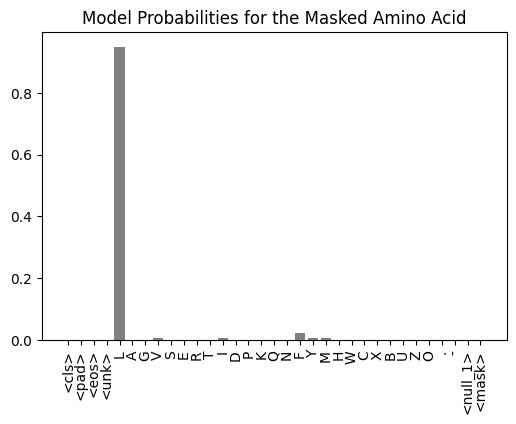

In [ ]:
letters = list(vocab_to_index.keys())
fig, ax = plt.subplots(figsize = (6,4))
plt.bar(letters, mask_probs, color = "grey")
plt.xticks(rotation = 90)
plt.title("Model Probabilities for the Masked Amino Acid")

### Rewrite the code as a more general form of MaskPredictor: Mask a sequence, make a predction, plot the predictions

In [ ]:
pip install --upgrade scikit-learn transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 92.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalled huggingface-hub-0.36.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.4
    Uninstalling tokenizers-0.21.4:
      Successfully uninstalled tokenizers-0.21.4
  Attempting uninstall: transformers
    Found existing installation: transformers 4.49.0
    Uninstalling transformers-4.49.0:
      Successfully u

In [ ]:
from dlfb.proteins.inspect import MaskPredictor

RuntimeError: Failed to import transformers.modeling_utils because of the following error (look up to see its traceback):
Failed to import transformers.generation.utils because of the following error (look up to see its traceback):
cannot import name 'get_chunk_n_rows' from 'sklearn.utils' (/usr/local/lib/python3.12/dist-packages/sklearn/utils/__init__.py)

In [ ]:
display([MaskPredictor])

[dlfb.proteins.inspect.MaskPredictor]

In [ ]:
# class MaskPredictor:
#   """Predict masked amino acids using a protein LM."""

#   def __init__(self, tokenizer: PreTrainedTokenizer, model:PreTrainedModel):
#     """Initialize with a tokenizer and a pretrained model."""
#     self.tokenizer = tokenizer
#     self.model = model

#   def plot_predictions(self, sequence:str, mask_index: int) -> Figure:
#     """Plot predicted probabilities for the masked amino acid"""
#     mask_probs = self.predict(sequence, mask_index)
#     fig, _ = plt.subplots(figsize = (6,4))
#     plt.bar(list(self.tokenizer.get_vocab().keys()), mask_probs, color = "grey")
#     plt.xticks(rotation = 90)
#     plt.title("Model Probabilities for the Masked Amino Acid\n"
#     f"at Index = {mask_index} (True Amino Acid = {sequence[mask_index]})."
#     )
#     return fig

#   def predict(self, sequence:str, mask_index: int) -> jax.Array:
#     """Return model probabilities for masked amino acid at a position."""
#     masked_sequence = self.mask_sequence(sequence, mask_index)
#     masked_inputs = self.tokenizer(masked_sequence, return_tensors = "pt")
#     model_outputs = self.model(**masked_inputs)
#     mask_preds = model_outputs.logits[0, mask_index + 1].detach().numpy()
#     mask_probs = jax.nn.softmax(mask_preds)
#     return mask_probs

#   @staticmethod
#   def mask_sequence(sequence:str, mask_index: int) -> str:
#     """Insert mask token at specified index in the input sequence."""
#     if mask_index < 0 or mask_index > len(sequence):
#       raise ValueError("Mask index out of sequence range")
#     return f"{sequence[0:mask_index]}<mask>{sequence[(mask_index + 1):]}"

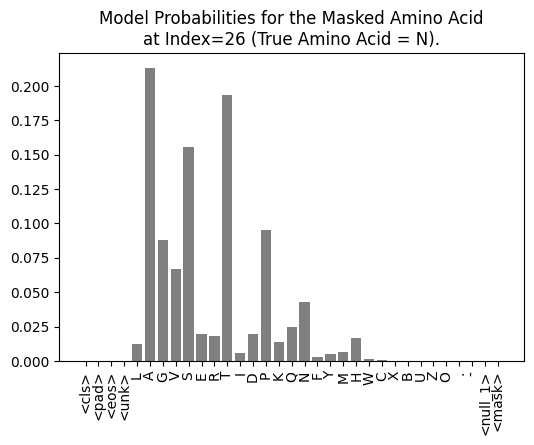

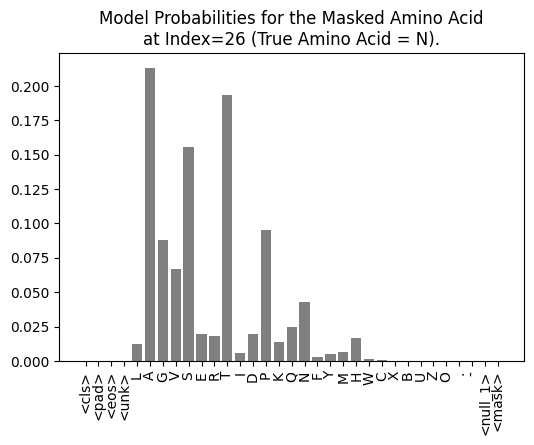

In [ ]:
#Trying mask predictor on a different amino acid position: index 26, which has the amino acid N

MaskPredictor(tokenizer, model=masked_lm_model).plot_predictions(
    sequence = insulin_sequence, mask_index = 26
)

This model does not strongly prefer a single amino acid, as it's assinging moderate probability to several options. This uncertainty may reflect biochemical flexibility of hat position (some regions of proteins can tolerate different residues)...These are 'permissive' positions.

# GENE ONTOLOGY: EXTRACELLULAR VERSUS MEMBRANE PROTEIN EMBEDDINGS

In [ ]:
import importlib
import PIL

if int(PIL.__version__.split('.')[0]) >= 11:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'Pillow==10.4.0', '-q'])
    # Force Python to use the newly installed version
    import importlib
    import pkg_resources
    pkg_resources.working_set = pkg_resources.WorkingSet()

/tmp/ipykernel_10453/747829152.py:9: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [ ]:
!pip install --upgrade --force-reinstall numpy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.8 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.2
    Uninstalling numpy-2.1.2:
      Successfully uninstalled numpy-2.1.2
  Attempting uninstall: narwhals
    Found existing installation: narwhals 2.22.1
    Uninstalling narwhals-2.22.1:
      Successfully uninstalled narwhals-2.22.1
  Attempting uninstall: joblib
 

In [ ]:
#Install the required dependencies, once the library is cloned:

#clone the repository that contains the dlfb library:

%cd /content
!rm -rf ./dlfb-clone/
!git clone "https://github.com/deep-learning-for-biology/dlfb.git" dlfb-clone --branch main
%cd dlfb-clone

/content
Cloning into 'dlfb-clone'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 129 (delta 23), reused 115 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 63.15 KiB | 1.05 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/dlfb-clone


In [ ]:
%%bash
curl -LsSf https://astral.sh/uv/install.sh | sh && \
export PATH="/root/.local/bin:${PATH}" && \
uv pip compile ./requirements/{base,dlfb,proteins,gpu}.txt \
  --color never \
  --constraint ./requirements/constraints.txt | \
uv pip install -r - --system

installing to /usr/local/bin
  uv
  uvx
everything's installed!


downloading uv 0.11.22 x86_64-unknown-linux-gnu
Resolved 146 packages in 3.85s
Using Python 3.12.13 environment at: /usr
Resolved 146 packages in 1.05s
Prepared 70 packages in 45.34s
Uninstalled 50 packages in 3.76s
Installed 71 packages in 903ms
 - absl-py==1.4.0
 + absl-py==2.4.0
 + adjusttext==1.3.0
 + biopython==1.85
 - cachetools==6.2.6
 + cachetools==7.1.4
 - certifi==2026.5.20
 + certifi==2022.12.7
 - charset-normalizer==3.4.7
 + charset-normalizer==2.1.1
 + chex==0.1.90
 - click==8.4.1
 + click==8.1.8
 - cryptography==48.0.1
 + cryptography==49.0.0
 - datasets==4.0.0
 + datasets==2.19.1
 + dlfb==0.1.1 (from file:///content/dlfb-clone)
 - filelock==3.29.2
 + filelock==3.29.0
 - flax==0.11.2
 + flax==0.10.4
 - fsspec==2025.3.0
 + fsspec==2024.3.1
 - google-auth==2.47.0
 + google-auth==2.55.0
 - google-cloud-storage==3.11.0
 + google-cloud-storage==3.0.0
 - grpcio==1.81.0
 + grpcio==1.81.1
 - huggingface-hub==1.18.0
 + huggingface-hub==0.36.0
 - idna==3.18
 + idna==3.4
 + ipinfo==

In [ ]:
#Provide the datasets that we need to access, download the necessary datasets

# NOTE: exclude models with '--no-models' flag
!dlfb-provision --chapter proteins


#IMport the dlfb package. The loading can sometimes be finicky; if you encounter
#issues then restart the runtime. You can re-run the load step without repeating everything

# Toggle JAX_DISABLE_JIT to True for easier debugging
%env JAX_DISABLE_JIT=False

try:
  import dlfb
except ImportError as exc:
  # NOTE: Packages installed in editable mode are not immediately
  #       recognized by Colab (https://stackoverflow.com/a/63312333).
  import site
  site.main()
  import dlfb

from dlfb.utils.display import display

Files Downloaded: 100% 22/22 [00:08<00:00,  2.54file/s]
env: JAX_DISABLE_JIT=False


In [ ]:
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler

X_train = np.array([[1.], [2.], [3.], [4.], [5.]])

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_train)

In [ ]:
test_array = np.array(range(0, 50, 5))
print(test_array)

[ 0  5 10 15 20 25 30 35 40 45]


In [ ]:
# # Issue, the version of transofrmers that I'm using expects an older version of _Ink (which was removed from Pillow 11.x)

# #Run this and then restart runtime:

# !pip install "Pillow<11.0" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 30.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.42.0 requires rich<14,>=12.4.4, but you have rich 15.0.0 which is incompatible.
pymc 5.28.5 requires cachetools<7,>=4.2.1, but you have cachetools 7.1.4 which is incompatible.
gradio 5.50.0 requires typer<1.0,>=0.12, but you have typer 0.7.0 which is incompatible.


In [ ]:
# For model tokenizer and torch:

from dlfb.proteins.inspect import MaskPredictor

In [ ]:
X_scaled

array([[-1.41421356],
       [-0.70710678],
       [ 0.        ],
       [ 0.70710678],
       [ 1.41421356]])

In [ ]:
display([MaskPredictor])

[dlfb.proteins.inspect.MaskPredictor]

Going to try using GO dataset to associate each unitProt protein accession and sequence with its known cellular location

In [ ]:
import pandas as pd

from dlfb.utils.context import assets

protein_df = pd.read_csv(assets("proteins/datasets/sequence_df_cco.csv"))
protein_df = protein_df[~protein_df["term"].isin(["GO:0005575", "GO:0110165"])]
num_proteins = protein_df["EntryID"].nunique()
protein_df.head()

,EntryID,Sequence,taxonomyID,term,aspect,Length
0,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0005622,CCO,258
1,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0031981,CCO,258
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0043229,CCO,258
3,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0043226,CCO,258
5,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0043231,CCO,258


In [ ]:
print(protein_df)

       EntryID                                           Sequence  taxonomyID  \
0       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...        9606   
1       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...        9606   
2       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...        9606   
3       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...        9606   
5       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...        9606   
...        ...                                                ...         ...   
337549  E7ER32  MPPLKSPAAFHEQRRSLERARTEDYLKRKIRSRPERSELVRMHILE...        9606   
337550  E7ER32  MPPLKSPAAFHEQRRSLERARTEDYLKRKIRSRPERSELVRMHILE...        9606   
337551  E7ER32  MPPLKSPAAFHEQRRSLERARTEDYLKRKIRSRPERSELVRMHILE...        9606   
337552  E7ER32  MPPLKSPAAFHEQRRSLERARTEDYLKRKIRSRPERSELVRMHILE...        9606   
337553  E7ER32  MPPLKSPAAFHEQRRSLERARTEDYLKRKIRSRPERSELVRMHILE...        9606   

              term aspect  

In [ ]:
#Filter protein df to proteins with a single location:

num_locations = protein_df.groupby("EntryID")["term"].nunique()
num_locations

,term
EntryID,
A0A023T787,13
A0A024QYT6,8
A0A024QYX0,8
A0A024QYX2,16
A0A024QYX3,11
...,...
X6RKS3,15
X6RLN4,3
X6RLP6,11


In [ ]:
len(num_locations)

21457

In [ ]:
proteins_one_location = num_locations[num_locations == 1].index
protein_df = protein_df[protein_df["EntryID"].isin(proteins_one_location)]

In [ ]:
go_function_examples = {
    "extracellular" : "GO:0005576",
    "membrane" : "GO:0016020"
}

go_function_examples.items()
go_function_examples.keys()
go_function_examples.values()

dict_values(['GO:0005576', 'GO:0016020'])

In [ ]:
sequences_by_function = {}

min_length = 100
max_length = 500
num_samples = 20

for function, go_term in go_function_examples.items():
  proteins_with_function = protein_df[
      (protein_df["term"] == go_term)
      & (protein_df["Length"] >= min_length)
      & (protein_df["Length"] <= max_length)
  ]

  print(
      f"Found {len(proteins_with_function)} human proteins\n"
      f"with the molecular function '{function}' ({go_term}),\n"
      f"and {min_length}<=length<={max_length}.\n"
      f"Sampling {num_samples} proteins at random. \n"
  )

  sequences = list (
      proteins_with_function.sample(num_samples, random_state = 42)["Sequence"]
  )

  sequences_by_function[function] = sequences


Found 164 human proteins
with the molecular function 'extracellular' (GO:0005576),
and 100<=length<=500.
Sampling 20 proteins at random. 

Found 65 human proteins
with the molecular function 'membrane' (GO:0016020),
and 100<=length<=500.
Sampling 20 proteins at random. 



We are going to extract the embeddings from these sequences. The function get_mean_embeddings computes the mean hidden state across each sequence (summarizing the model's representation of protein sequences):



In [ ]:
from dlfb.proteins.dataset import get_mean_embeddings
from transformers import AutoTokenizer, EsmModel

display([get_mean_embeddings])

[<function dlfb.proteins.dataset.get_mean_embeddings(sequences: list[str], tokenizer: transformers.tokenization_utils.PreTrainedTokenizer, model: transformers.modeling_utils.PreTrainedModel, device: torch.device | None = None) -> numpy.ndarray>]

In [ ]:
# def get_mean_embeddings(
#     sequences = list[str],
#     tokenizer: PreTrainedTokenizer,
#     model: PreTrainedModel,
#     device: torch.device | None = None,
# ) -> mp.ndarray:
# """ Compute mean embedding for each sequence using a protein LM. """

# if not device:
#   device = get_device()

#   # Tokenize input sequences and make them an equal length:
#   model_inputs = tokenizer(sequences, padding = True, return_tensors = "pt")

#   #MOve tokenized inputs to the target CPU or GPU device
#   model_inputs = {k: v.to(device) for k, v in model_inputs.item()}

#   # Move model to the target device and set to evaluation mode
#   model = model.to(device)
#   model.eval()

#   #Forward pass without gradient tracking to obtain embeddings.
#   with torch.no_grad():
#     outputs = model(**model_inputs)
#     mean_embeddings = outputs.last_hidden_state.mean(dim = 1)

#     return mean_embeddings.detatch().cpu().numpy()

Extract embeddings using smaller ESM2 model (makes 320-dim representation and needs less memory)

In [ ]:
model_checkpoint = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Calculate the embeddings now using get_mean_embeddings

In [ ]:
protein_embeddings = {
    loc: get_mean_embeddings(sequences_by_function[loc], tokenizer, model)
    for loc in ["extracellular", "membrane"]
}

#Reformat/clean the data:

labels, embeddings = [], []
for location, embedding in protein_embeddings.items():
  labels.extend([location] * embedding.shape[0])
  embeddings.append(embedding)
  print (f"{location}: {embedding.shape}")

extracellular: (20, 320)
membrane: (20, 320)


For each sequences (regardless of length), we obtain a fixed-size vector of 320 dimensions. These vectors correspond to the mean of the final hidden layer activations across all tokens in the sequence


Visualize these embeddings to see how they relate to protein localization in 2-D using t-SNE

Text(0, 0.5, 'Second Dimension')

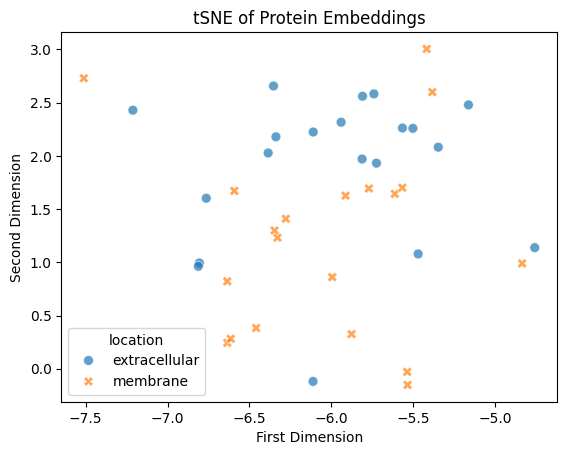

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE

embeddings_tsne = TSNE(n_components = 2, random_state = 42).fit_transform(
    np.vstack(embeddings)
)

embeddings_tsne_df = pd.DataFrame(
    {
        "first_dimension" : embeddings_tsne[:, 0],
        "second_dimension" : embeddings_tsne[:, 1],
        "location": np.array(labels)
    }
)

fig = sns.scatterplot(
    data = embeddings_tsne_df,
    x = "first_dimension",
    y = "second_dimension",
    hue = "location",
    style = "location",
    s = 50,
    alpha = 0.7
)
fig.set_title("tSNE of Protein Embeddings")
fig.set_xlabel("First Dimension")
fig.set_ylabel("Second Dimension")

# PREPARING AND CLEANING ML READY DATA
# MFO (MOLECULAR FUNCTIONS)

Loading the CAFA3 Data (CAFA = Critical Assessment of Functional Annotation)

In [ ]:
#Download the CAFA3 Targets and CAFA3 Training Data files from the CAFA website

labels = pd.read_csv(
    assets("proteins/datasets/train_terms.tsv.zip"), sep = "\t", compression = "infer"
)

print(labels)

#EntryID = UniProt ID of protein, term = GO accession code for protein function, aspect =
# the GO category (BPO = Biological process, MFO = molecular funciton, CCO = cellular component)

            EntryID        term aspect
0        A0A009IHW8  GO:0008152    BPO
1        A0A009IHW8  GO:0034655    BPO
2        A0A009IHW8  GO:0072523    BPO
3        A0A009IHW8  GO:0044270    BPO
4        A0A009IHW8  GO:0006753    BPO
...             ...         ...    ...
5363858      X5L565  GO:0050649    MFO
5363859      X5L565  GO:0016491    MFO
5363860      X5M5N0  GO:0005515    MFO
5363861      X5M5N0  GO:0005488    MFO
5363862      X5M5N0  GO:0003674    MFO

[5363863 rows x 3 columns]


Get corresponding human-readable descriptions for the GO term column; onotology is stored in graph format as a .obo file; use obonet Python library to parse it

In [ ]:
from dlfb.proteins.dataset import get_go_term_descriptions

display(["import obonet", get_go_term_descriptions])

['import obonet',
 <function dlfb.proteins.dataset.get_go_term_descriptions(store_path: str) -> pandas.core.frame.DataFrame>]

In [ ]:
go_term_descriptions = get_go_term_descriptions(
    store_path = assets("proteins/datasets/go_term_descriptions.csv")
)

print(go_term_descriptions)

             term                                        description
0      GO:0000001                          mitochondrion inheritance
1      GO:0000002                   mitochondrial genome maintenance
2      GO:0000006  high-affinity zinc transmembrane transporter a...
3      GO:0000007  low-affinity zinc ion transmembrane transporte...
4      GO:0000009             alpha-1,6-mannosyltransferase activity
...           ...                                                ...
40209  GO:2001313  UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40210  GO:2001314  UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40211  GO:2001315  UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40212  GO:2001316                       kojic acid metabolic process
40213  GO:2001317                    kojic acid biosynthetic process

[40214 rows x 2 columns]


In [ ]:
labels.head(6)

,EntryID,term,aspect
0,A0A009IHW8,GO:0008152,BPO
1,A0A009IHW8,GO:0034655,BPO
2,A0A009IHW8,GO:0072523,BPO
3,A0A009IHW8,GO:0044270,BPO
4,A0A009IHW8,GO:0006753,BPO
5,A0A009IHW8,GO:1901292,BPO


In [ ]:
labels = labels.merge(go_term_descriptions, on = "term")
labels

,EntryID,term,aspect,description
0,A0A009IHW8,GO:0008152,BPO,metabolic process
1,A0A009IHW8,GO:0034655,BPO,nucleobase-containing compound catabolic process
2,A0A009IHW8,GO:0072523,BPO,purine-containing compound catabolic process
3,A0A009IHW8,GO:0006753,BPO,nucleoside phosphate metabolic process
4,A0A009IHW8,GO:1901292,BPO,nucleoside phosphate catabolic process
...,...,...,...,...
4933953,X5L565,GO:0050649,MFO,testosterone 6-beta-hydroxylase activity
4933954,X5L565,GO:0016491,MFO,oxidoreductase activity
4933955,X5M5N0,GO:0005515,MFO,protein binding
4933956,X5M5N0,GO:0005488,MFO,binding


Now we have human-readable values for each GO term. Let's see which MFs are most common:

In [ ]:
labels = labels[labels["aspect"] == "MFO"]
print(labels['description'].value_counts())

description
molecular_function                                78637
binding                                           57380
protein binding                                   47987
catalytic activity                                25324
heterocyclic compound binding                     12694
                                                  ...  
lovastatin nonaketide synthase activity               1
histone H3K37 methyltransferase activity              1
mitochondrion-plasma membrane adaptor activity        1
phenylacetate 2-hydroxylase activity                  1
NAD-dependent protein biotinidase activity            1
Name: count, Length: 6973, dtype: int64


## Now load the protein sequences associated with each protein ID, stored in train_sequences.fasta

In [ ]:
#Convert fasta sequences into pd df

from Bio import SeqIO

sequences_file = assets("proteins/datasets/train_sequences.fasta")
fasta_sequences = SeqIO.parse(open(sequences_file), "fasta")

data = []
for fasta in fasta_sequences:
  data.append(
      {
      "EntryID": fasta.id,
       "Sequence": str(fasta.seq),
       "Length": len(fasta.seq)
       }
  )

sequence_df = pd.DataFrame(data)
print(sequence_df)


           EntryID                                           Sequence  Length
0           P20536  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...     218
1           O73864  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...     354
2           O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...     258
3       A0A0B4J1F4  MGGEAGADGPRGRVKSLGLVFEDESKGCYSSGETVAGHVLLEAAEP...     415
4           P54366  MVETNSPPAGYTLKRSPSDLGEQQQPPRQISRSPGNTAAYHLTTAM...     415
...            ...                                                ...     ...
142241  A0A286YAI0  METEVDDFPGKASIFSQVNPLYSNNMKLCEAERYDFQHSEPKTMKS...     450
142242  A0A1D5NUC4  MSAAASAEMIETPPVLNFEEIDYKEIEVEEVVGRGAFGVVCKAKWR...     643
142243      Q5RGB0  MADKGPILTSVIIFYLSIGAAIFQILEEPNLNSAVDDYKNKTNNLL...     448
142244  A0A2R8QMZ5  MGRKKIQITRIMDERNRQVTFTKRKFGLMKKAYELSVLCDCEIALI...     459
142245  A0A8I6GHU0  HCISSLKLTAFFKRSFLLSPEKHLVLLRDGRTLIGFLRSIDQFANL...     138

[142246 rows x 3 columns]


Now need to isolate the human proteins, using associated taxonomy file

In [ ]:
taxonomy_file = assets("proteins/datasets/train_taxonomy.tsv.zip")
taxonomy = pd.read_csv(taxonomy_file, sep = "\t", compression = "infer")
print(taxonomy)

           EntryID  taxonomyID
0           Q8IXT2        9606
1           Q04418      559292
2           A8DYA3        7227
3           Q9UUI3      284812
4           Q57ZS4      185431
...            ...         ...
142241      Q5TD07        9606
142242      A8BB17        7955
142243  A0A2R8QBB1        7955
142244      P0CT72      284812
142245      Q9NZ43        9606

[142246 rows x 2 columns]


Merge the taxonomy file with the sequence df and only include proteins with taxonomyID = 9606 (Homo sapiens)

In [ ]:
sequence_df = sequence_df.merge(taxonomy, on = "EntryID")
sequence_df = sequence_df[sequence_df["taxonomyID"] == 9606]

In [ ]:
#Check number of unique proteins and MFs in our filtered dataset

sequence_df = sequence_df.merge(labels, on = 'EntryID')
print(
    f"Dataset contains {sequence_df["EntryID"].nunique()} human proteins"
    f" with {sequence_df["term"].nunique()} molecular functions."
)

Dataset contains 16336 human proteins with 4101 molecular functions.


In [ ]:
print(sequence_df)

       EntryID                                           Sequence  Length  \
0       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...     258   
1       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...     258   
2       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...     258   
3       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...     258   
4       O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...     258   
...        ...                                                ...     ...   
152521  Q549H9  MMEVESSYSDFISCDRTGRRNAVPDIQGDSEAVSVRKLAGDMGELA...      76   
152522  Q549H9  MMEVESSYSDFISCDRTGRRNAVPDIQGDSEAVSVRKLAGDMGELA...      76   
152523  Q86TI6  MGAAAVRWHLCVLLALGTRGRLAGGSGLPGSVDVDECSEGTDDCHI...     347   
152524  Q86TI6  MGAAAVRWHLCVLLALGTRGRLAGGSGLPGSVDVDECSEGTDDCHI...     347   
152525  Q86TI6  MGAAAVRWHLCVLLALGTRGRLAGGSGLPGSVDVDECSEGTDDCHI...     347   

        taxonomyID        term aspect  \
0             9606  GO:0003676    

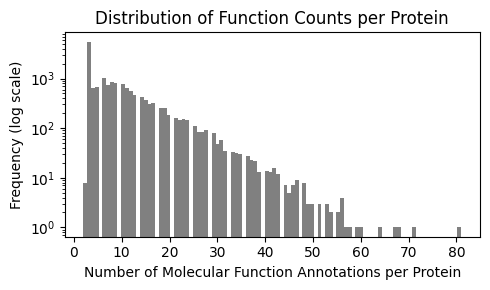

In [ ]:
#Let's exame the distribution of molecular functions. Distribution of number of
#functions per protein:
import matplotlib.pyplot as plt

sequence_df.groupby("EntryID")["term"].nunique().plot.hist(
    bins = 100, figsize = (5,3), color = "grey", log = True
)
plt.xlabel("Number of Molecular Function Annotations per Protein")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Function Counts per Protein")
plt.tight_layout()

We see that most proteins have a well-define function, while other are invovled in a wide variety of molecular functions (enzymes, binding, multi-pathways). Our ML model needs to assign multiple function labels to a single protein and recognize rarer proteins too.

In [ ]:
sequence_df.groupby("EntryID")["term"].nunique()

,term
EntryID,
A0A024R0L9,3
A0A024R0Y4,3
A0A024R1L7,3
A0A024R275,3
A0A024R4B0,3
...,...
W5RWE1,3
W5XKT8,3
W6CW81,3


In [ ]:
sequence_df.groupby("EntryID")["term"].value_counts()

EntryID     term      
A0A024R0L9  GO:0003674    1
            GO:0005488    1
            GO:0005515    1
A0A024R0Y4  GO:0003674    1
            GO:0005488    1
                         ..
X5D7E3      GO:0008134    1
            GO:0019899    1
            GO:0031369    1
            GO:0031370    1
            GO:0140297    1
Name: count, Length: 152526, dtype: int64

In [ ]:
#Take a closer look at the most frequent molecular function labels:

uninteresting_functions = [
    "GO:003674", #molecular function, applies to 100% of proteins
    "GO: 005488", #binding, applies to 93% of proteins
    "GO: 005515" #protein binding, applies to 89% of proteins
  ]

sequence_df = sequence_df[-sequence_df["term"].isin(uninteresting_functions)]
sequence_df.shape

(152526, 7)

In [ ]:
#Now get rid of the really rare MFs proteins. Our model needs enough training examples per
#function to actually learn

common_functions = (
    sequence_df["term"]
    .value_counts()[sequence_df["term"].value_counts() >= 50]
    .index
)

sequence_df = sequence_df[sequence_df["term"].isin(common_functions)]
sequence_df["term"].value_counts()

,count
term,
GO:0003674,16336
GO:0005488,15148
GO:0005515,14541
GO:0003824,3875
GO:1901363,2943
...,...
GO:0005230,52
GO:0005516,51
GO:0031490,51


Decisions about thresholds are effectively hyperparameters and should be tuned based on specific task, dataset size, and model capacity

In [ ]:
#Reshape DF so each row corresponds to one protein and each column = MF label.
#Use pandas pivot function

sequence_df = (
    sequence_df[["EntryID", "Sequence", "Length", "term"]]
    .assign(value = 1)
    .pivot(
        index = ["EntryID", "Sequence", "Length"], columns = "term", values = "value"
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)

print(sequence_df)

term      EntryID                                           Sequence  Length  \
0      A0A024R0L9  MHAAEIMGPLSAPPCTEHIKWKGLLLTVETPKPSISSSNLNPREAM...     219   
1      A0A024R0Y4  MDRLGSFSNDPSDKPPCRGCSSYLMEPYIKCAECGPPPFFLCLQCF...     443   
2      A0A024R1L7  MDSRFPDFQDLDLEPERACHDAAGTLEVDFFLFLNFGTVDLAVRKE...     135   
3      A0A024R275  MPRADCIMRHLPYFCRGQVVRGFGRGSKQLGIPTANFPEQVVDNLP...     162   
4      A0A024R4B0  MKKVKKKRSEARRHRDSTSQHASSNSTSQQPSPESTPQQPSPESTP...     183   
...           ...                                                ...     ...   
16331      W5RWE1  MKVLILACLVALALARETIESLSSSEESITEYKQKVEKVKHEDQQQ...     226   
16332      W5XKT8  MALLALASAVPSALLALAVFRVPAWACLLCFTTYSERLRICQMFVG...     324   
16333      W6CW81  MESKYKEILLLTSLDNITDEELDRFKCFLPDEFNIATGKLHTLNST...     113   
16334      X5D778  MPKGGCPKAPQQEELPLSSDMVEKQTGKKDKDKVSLTKTPKLERGD...     421   
16335      X5D7E3  MLDLTSRGQVGTSRRMAEAACSAHFLETTPTPNPPTTEEEKTESNQ...     237   

term   GO:0000166  GO:0000287  GO:00009

In [ ]:
sequence_df["EntryID"].nunique()

16336

In [ ]:
sequence_df["Sequence"].nunique()

16209

Next let's apply a threshold for protein sequence length size, memory can get intensive so only less than or equal to 500

In [ ]:
print(sequence_df.shape)
sequence_df = sequence_df[sequence_df["Length"] <= 500]
print(sequence_df.shape)

(16336, 309)
(9692, 309)


## Splitting the Dataset into Subsets: Training, Validation, Test

In [ ]:
#Training: used to fit the model, model sees this during training and learn patterns
#Validation: Used to evaluate model's performance during development --> used to tune hyperparameters
#Test: Used only once for final evaluation. Avoid using this for model design decisions

#Split proteins by their EntryID so each protein only appears in one subset

from sklearn.model_selection import train_test_split

#60% of proteins go in training set:
train_sequence_ids, valid_test_sequence_ids = train_test_split(
    list(set(sequence_df["EntryID"])), test_size = 0.40, random_state = 42
)

#Split the remaining 40$ evenly between validation and test sets
valid_sequence_ids, test_sequence_ids = train_test_split(
    valid_test_sequence_ids, test_size = 0.50, random_state = 42
)

#Then extract the rows for each split from the sequence_df:

sequence_splits = {
    "train": sequence_df[sequence_df["EntryID"].isin(train_sequence_ids)],
    "valid": sequence_df[sequence_df["EntryID"].isin(valid_sequence_ids)],
    "test": sequence_df[sequence_df["EntryID"].isin(test_sequence_ids)]
}

In [ ]:
for split, df in sequence_splits.items():
  print(f"{split} has {len(df)} entries.")

train has 5815 entries.
valid has 1938 entries.
test has 1939 entries.


## CONVERTING PROTEIN SEQUENCES INTO THEIR MEAN EMBEDDINGS

Convert the sequences from each dataset split into their corresponding mean embeddings. Use GP to speed up computation, and also compute embeddings only once, store them to disk, and load later

In [ ]:
from dlfb.proteins.dataset import (
  load_sequence_embeddings,
  store_sequence_embeddings,
)

display([store_sequence_embeddings, load_sequence_embeddings])

[<function dlfb.proteins.dataset.store_sequence_embeddings(sequence_df: pandas.core.frame.DataFrame, store_prefix: str, tokenizer: transformers.tokenization_utils.PreTrainedTokenizer, model: transformers.modeling_utils.PreTrainedModel, batch_size: int = 64, force: bool = False) -> None>,
 <function dlfb.proteins.dataset.load_sequence_embeddings(store_file_prefix: str, model_checkpoint: str) -> pandas.core.frame.DataFrame>]

Using the powerful but more computationally expensive ESM2 model with 640-dim embeddings and store the embeddings for each split with store_seqeunce_embeddings function

In [ ]:
model_checkpoint = "facebook/esm2_t30_150M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

for split, df in sequence_splits.items():
  store_sequence_embeddings(
      sequence_df = df,
      store_prefix = assets(f"proteins/datasets/protein_dataset_{split}"),
      tokenizer = tokenizer,
      model = model
  )

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
train_df = load_sequence_embeddings(
    assets("proteins/datasets/protein_dataset_train"),
    model_checkpoint = model_checkpoint
)

print(train_df)

         EntryID                                           Sequence  Length  \
0     A0A0C4DG62  MAHVGSRKRSRSRSRSRGRGSEKRKKKSRKDTSRNCSASTSQERSK...     218   
1     A0A1B0GTB2   MVITSENDEDRGGQEKESKEESVLAMLGIIGTILNLIVIIFVYIYTTL      48   
2         A0AVI4  MDSPEVTFTLAYLVFAVCFVFTPNEFHAAGLTVQNLLSGWLGSEDA...     362   
3         A0PJW6  MAAPWRRWPTGLLAVLRPLLTCRPLQGTTLQRDVLLFEHDRGRFFT...     202   
4         A1L167  MKELQDIARLSDRFISVELVDESLFDWNVKLHQVDKDSVLWQDMKE...     161   
...          ...                                                ...     ...   
3569      Q9Y6N5  MVPLVAVVSGPRAQLFACLLRLGTQQVGPLQLHTGASHAARNHYEV...     450   
3570      Q9Y6P5  MRLAAAANEAYTAPLAVSGLLGCKQCGGGRDQDEELGIRIPRPLGQ...     492   
3571      Q9Y6W5  MPLVTRNIEPRHLCRQTLPSVRSELECVTNITLANVIRQLGSLSKY...     498   
3572      Q9Y6W6  MPPSPLDDRVVVALSRPVRPQDLNLCLDSSYLGSANPGSNSHPPVI...     482   
3573      Q9Y6Y9  MLPFLFFSTLFSSIFTEAQKQYWVCNSSDASISYTYCDKMQYPISI...     160   

      GO:0000166  GO:0000287  GO:0000976  GO:000097

ME:1 to ME:640 represent the mean-pooled hidden states from final layer of ESM2 model (fixed-length numerical summary of each protein seqeunce). The embeddings capture biochemical and structural information learned during pretraining --> input for the classifier

In [ ]:
#To make our DFs into a TensorFlow dataset for each split preparation
from dlfb.proteins.dataset import convert_to_tfds

display(["import tensorflow as tf", convert_to_tfds])

['import tensorflow as tf',
 <function dlfb.proteins.dataset.convert_to_tfds(df: pandas.core.frame.DataFrame, embeddings_prefix: str = 'ME:', target_prefix: str = 'GO:', is_training: bool = False, shuffle_buffer: int = 50) -> tensorflow.python.data.ops.dataset_ops.DatasetV2>]

Use convert_to_tfds function to build a TensorFlow dataset from the training DF

In [ ]:
train_ds = convert_to_tfds(train_df, is_training=True)

#Now get batches of the datasets. Batch the dataset, convert to NumPy iterator
#and retrieve next batch by calling next

batch_size = 32

batch = next(train_ds.batch(batch_size).as_numpy_iterator())
batch["embedding"].shape, batch["target"].shape

((32, 640), (32, 303))

To streamline dataset setup: helper function, build_dataset

In [ ]:
from dlfb.proteins.dataset import build_dataset

display([build_dataset])

[<function dlfb.proteins.dataset.build_dataset(store_file_prefix: str, model_checkpoint: str) -> dict[str, tensorflow.python.data.ops.dataset_ops.DatasetV2]>]

In [ ]:
#Above function will load the saved eman embeddings from disk for all 3 splits
#and construct tf.data.Dataset objects that area ready for training:

dataset_splits = build_dataset(
    assets("proteins/datasets/protein_dataset"), model_checkpoint = model_checkpoint
)

In [ ]:
dataset_splits

{'train': <_RepeatDataset element_spec={'embedding': TensorSpec(shape=(640,), dtype=tf.float32, name=None), 'target': TensorSpec(shape=(303,), dtype=tf.int64, name=None)}>,
 'valid': <_TensorSliceDataset element_spec={'embedding': TensorSpec(shape=(640,), dtype=tf.float32, name=None), 'target': TensorSpec(shape=(303,), dtype=tf.int64, name=None)}>,
 'test': <_TensorSliceDataset element_spec={'embedding': TensorSpec(shape=(640,), dtype=tf.float32, name=None), 'target': TensorSpec(shape=(303,), dtype=tf.int64, name=None)}>}

## NOW TRAINING THE MODEL

Train a simple Flax linear model on top of the mean protein embeddings. The protein sequences now have a fixed-size embeddings. We want to predict which of the 303 molecular functions each protein performs. This is a MULTILABEL CLASSIFICATION PROBLEM (each protein can be associated with several function labels simultaneously)

In [ ]:
import jax
import numpy as np
import pandas as pd

from dlfb.proteins.dataset import (
  build_dataset,
  get_go_term_descriptions,
  load_sequence_embeddings,
)
from dlfb.utils.context import assets

go_term_descriptions = get_go_term_descriptions(
  store_path=assets("proteins/datasets/go_term_descriptions.csv")
)

model_checkpoint = "facebook/esm2_t30_150M_UR50D"

train_df = load_sequence_embeddings(
  store_file_prefix=f"{assets('proteins/datasets/protein_dataset')}_train",
  model_checkpoint=model_checkpoint,
)

dataset_splits = build_dataset(
  assets("proteins/datasets/protein_dataset"), model_checkpoint=model_checkpoint
)
batch = next(dataset_splits["train"].as_numpy_iterator())

In [ ]:
from dlfb.proteins.model import Model

display(
  ["import flax.linen as nn\nfrom flax.training import train_state\n", Model]
)

['import flax.linen as nn\nfrom flax.training import train_state\n',
 dlfb.proteins.model.Model]

This ligthweight model:

- Used nn.Sequential to stack layers (clean and readable definition)
- GELU (Gaussian Error Linear Unit) activation function, which is a smooth, nonlinear alternative to ReLU
- Final layer is nn.Dense layer projection to the number of functional labels (num_targets). It returns logits, not probabilities --> apply activation (like sigmoid) inside the lsos function to conver these into predicted probabilities.
- Model is frozen on top of the ESM2 embeddings (does not update transformer wieghts. It learns onl yto map fixed embeddings to functional labels)

Instantiate the model with the correct number of output targets, based on how many GO terms we have in training:

In [ ]:
targets = list(train_df.columns[train_df.columns.str.contains("GO:")])
mlp = Model(num_targets = len(targets))

In [ ]:
mlp

Model(
    # attributes
    num_targets = 303
    dim = 256
)

## DEFINING THE TRAINING LOOP:

Forward pass through the model, computing the loss, calculating gradients, and updating the model parameters using those gradients

In [ ]:
from dlfb.proteins.train import train_step

display([train_step])

[<PjitFunction of <function train_step at 0x7a1f44f40360>>]

In [ ]:
from dlfb.proteins.train import compute_metrics

display(["import sklearn", compute_metrics])

['import sklearn',
 <function dlfb.proteins.train.compute_metrics(targets: numpy.ndarray, probs: numpy.ndarray, thresh=0.5) -> dict[str, float]>]

In [ ]:
from dlfb.proteins.train import compute_metrics, eval_step, calculate_per_target_metrics, train


Sigmoid activation and binary cross-entropy loss (good for multilabel classification). Logits go through sigmoid activation (no softmax bc we want independent yes/no predictions for each possible protein function). And each protein can have many functions at once.

@jax.jit compiles the training step for better performance

THROUGH COMPUTE_METRICS WE CAN EVALUATE EACH FUNCTION LABEL WITH:

Accuracy (fraction of correct predictions across all labels), but can be misleading with imbalanced multilabel data like this bc most labels are zero ---> model that alwasy predicts no function is still accurate

Recall: Proportion of actual function labels the model predicts correctly TP / FN + TP . High recall - model doesn't miss many true functions

Precision: Proportion of predicted function labels that are correct (TP / FP + TP). High precision = avoids false alarms

Area under the precision-recall curve (auPRC): Summarizes the tradeoff between precision and recall at dif thresholds.

Area under the receiving operating characteristic curve (auROC); Measures how well the model can distinguish positive from negative examples across all thresholds.



NOTE: For each protein, apply sigmoid to its 303 logits to get function probabilities, threshold those probabilities to get binary (y/n) predictions, compare thsee to the true function labels to compute performanc metrics --> repeat for every protein in every batch and average resulting metrics across proteins (reports performance per protein, not go term)

## TRAINING STEP

In [ ]:
display([train])

[<function dlfb.proteins.train.train(state: flax.training.train_state.TrainState, dataset_splits: dict[str, tensorflow.python.data.ops.dataset_ops.DatasetV2], batch_size: int, num_steps: int = 300, eval_every: int = 30)>]

NOTES ON THIS TRAINING LOOP:

Efficient batch sampling: uses .as_numpy_iterator() and .repeat() in the dataset for infinite looping over data

Regular evaluation: Every eval_every step the model is evaluated for all metrics

Metric aggregation: validation metrics are computed batch-wise and then averaged across all batches with pd.DataFrame(....).mean(axis = 0) for updated performance

In [ ]:
import optax

from dlfb.utils.restore import restorable

#Start training with dummy data from a single batch

rng = jax.random.PRNGKey(42)
rng, rng_init = jax.random.split(key = rng, num = 2)

state, metrics = restorable(train)(
    state = mlp.create_train_state(
        rng = rng_init, dummy_input = batch["embedding"], tx = optax.adam(0.001)
    ),
    dataset_splits = dataset_splits,
    batch_size = 32,
    num_steps = 300,
    eval_every = 30,
    store_path = assets("proteins/models/mlp"),
)

With a batch size of 32 and around 2100 examples --> roughly 66 stesp for the model to see the entire training data + num_steps = 300 --> model will see each training data point several times

In [ ]:
train_df.shape

(3574, 946)

In [ ]:
train_df.head(10)

,EntryID,Sequence,Length,GO:0000166,GO:0000287,GO:0000976,GO:0000977,GO:0000978,GO:0000981,GO:0000987,...,ME:631,ME:632,ME:633,ME:634,ME:635,ME:636,ME:637,ME:638,ME:639,ME:640
0,A0A0C4DG62,MAHVGSRKRSRSRSRSRGRGSEKRKKKSRKDTSRNCSASTSQERSK...,218,0,0,0,0,0,0,0,...,0.115807,0.015930,0.238635,-0.131061,0.067720,0.062926,0.040286,0.030008,-0.033614,0.023891
1,A0A1B0GTB2,MVITSENDEDRGGQEKESKEESVLAMLGIIGTILNLIVIIFVYIYTTL,48,0,0,0,0,0,0,0,...,0.154284,0.043895,0.140837,-0.033439,0.069197,0.129815,-0.044294,0.023842,-0.020635,0.125583
2,A0AVI4,MDSPEVTFTLAYLVFAVCFVFTPNEFHAAGLTVQNLLSGWLGSEDA...,362,0,0,0,0,0,0,0,...,0.039095,-0.071286,-0.450992,0.023398,-0.159405,0.153848,-0.075747,0.024440,-0.123321,0.020945
3,A0PJW6,MAAPWRRWPTGLLAVLRPLLTCRPLQGTTLQRDVLLFEHDRGRFFT...,202,0,0,0,0,0,0,0,...,0.003744,-0.106157,-0.036542,-0.126789,0.032678,0.139719,-0.067211,0.038010,-0.047248,-0.053881
4,A1L167,MKELQDIARLSDRFISVELVDESLFDWNVKLHQVDKDSVLWQDMKE...,161,0,0,0,0,0,0,0,...,0.218363,-0.096935,0.340459,0.107160,0.030034,0.084888,-0.079358,-0.066251,-0.063700,-0.014334
5,A1L3X0,MAFSDLTSRTVHLYDNWIKDADPRVEDWLLMSSPLPQTILLGFYVY...,281,0,0,0,0,0,0,0,...,0.035149,0.008788,0.054589,-0.044882,0.081743,0.149900,0.023200,-0.013469,-0.246399,-0.124898
6,A1XBS5,MMRRTLENRNAQTKQLQTAVSNVEKHFGELCQIFAAYVRKTARLRD...,289,0,0,0,0,0,0,0,...,0.101876,-0.011710,-0.146851,-0.037271,-0.052477,0.117427,-0.013705,0.009637,-0.102270,0.003524
7,A1Z1Q3,MYPSNKKKKVWREEKERLLKMTLEERRKEYLRDYIPLNSILSWKEE...,425,0,0,0,0,0,0,0,...,0.030955,0.100941,-0.004997,0.000123,0.025273,0.001166,-0.107233,0.043648,-0.070149,-0.139205
8,A2RU49,MSSGNYQQSEALSKPTFSEEQASALVESVFGLKVSKVRPLPSYDDQ...,373,0,0,0,0,0,0,0,...,0.010353,0.031041,-0.001788,-0.000016,-0.117735,0.105936,-0.094491,0.039584,-0.158513,-0.097443
9,A2RU54,MGSKEDAGKGCPAAGGVSSFTIQSILGGGPSEAPREPVGWPARKRS...,273,0,0,0,0,0,0,0,...,-0.019600,0.044294,0.209276,-0.180309,0.023410,0.129474,-0.024609,-0.021492,-0.013532,-0.166318


In [ ]:
train_df["EntryID"].nunique() == len(train_df)

True

Now evaluate the training dynamics and performance on the validation set

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from dlfb.utils.metric_plots import DEFAULT_SPLIT_COLORS

#Plotr training loss curve

learning_data = pd.concat(
    pd.DataFrame(metrics[split]).melt("step").assign(split = split)
    for split in ["train", "valid"]
)

In [ ]:
learning_data.head()

,step,variable,value,split
0,0,loss,0.695990,train
1,1,loss,0.672567,train
2,2,loss,0.650785,train
3,3,loss,0.620128,train
4,4,loss,0.581017,train


In [ ]:
learning_data.shape

(360, 4)

In [ ]:
learning_data[learning_data["variable"] != "loss"]

,step,variable,value,split
10,0,accuracy,0.716877,valid
11,30,accuracy,0.976323,valid
12,60,accuracy,0.976451,valid
13,90,accuracy,0.976321,valid
14,120,accuracy,0.977196,valid
15,150,accuracy,0.977575,valid
16,180,accuracy,0.977629,valid
17,210,accuracy,0.978354,valid
18,240,accuracy,0.978162,valid
19,270,accuracy,0.978488,valid


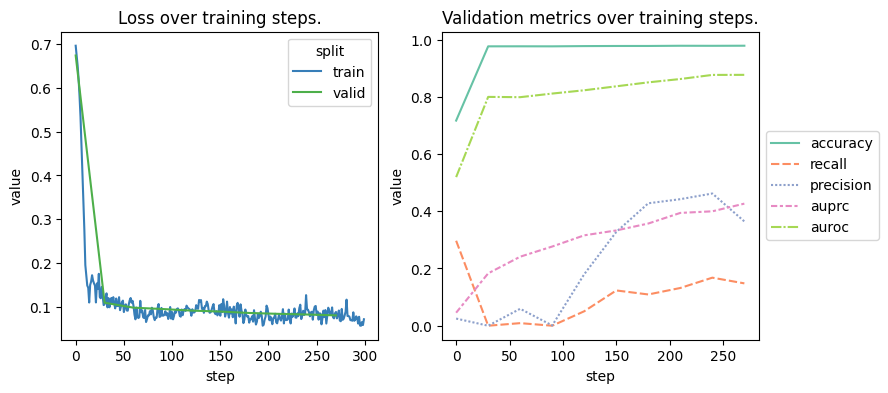

In [ ]:
#Plot data
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (9,4))

sns.lineplot(
    ax = ax[0],
    x = "step",
    y = "value",
    hue = "split",
    data = learning_data[learning_data["variable"] == "loss"],
    palette = DEFAULT_SPLIT_COLORS,
)
ax[0].set_title("Loss over training steps.")

#Plot validation metrics curve
sns.lineplot(
    ax = ax[1],
    x = "step",
    y = "value",
    hue = "variable",
    style = "variable",
    data = learning_data[learning_data["variable"] != "loss"],
    palette = "Set2",
)
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
ax[1].set_title("Validation metrics over training steps.");

Rapid convergence in the loss curve on the left and then on the right, auPRC, precision, and recall improve gradually. But accuracy and auroc are high due to class imablances (since most function labels are negative i.e a protein lacks majority of all possible protein functions).

auPRC steadily improves and does not fully plateau, suggestion model could benefit from more training

Precision increases faster than recall (model might fail to capture some of the TPs but is increasingly confident in its predictions)

## EXAMINING MODEL PREDICTIONS:

Explore the model's strengths and weaknesses. Start by making predictiosn for entire validation set and storing them in DF

In [ ]:
valid_df = load_sequence_embeddings(
    store_file_prefix = f"{assets('proteins/datasets/protein_dataset')}_valid",
    model_checkpoint = model_checkpoint,
)

#Use batch size of 1 to avoid dropping the remainder:

valid_probs = []
for valid_batch in dataset_splits['valid'].batch(1).as_numpy_iterator():
  logits = state.apply_fn({"params": state.params}, x = valid_batch["embedding"])
  valid_probs.extend(jax.nn.sigmoid(logits))

valid_true_df = valid_df[["EntryID"] + targets].set_index("EntryID")
valid_prob_df = pd.DataFrame(
    np.stack(valid_probs), columns = targets, index = valid_true_df.index
)

In [ ]:
valid_df.head()

,EntryID,Sequence,Length,GO:0000166,GO:0000287,GO:0000976,GO:0000977,GO:0000978,GO:0000981,GO:0000987,...,ME:631,ME:632,ME:633,ME:634,ME:635,ME:636,ME:637,ME:638,ME:639,ME:640
0,A1A4Y4,MEAMNVEKASADGNLPEVISNIKETLKIVSRTPVNITMAGDSGNGM...,181,0,0,0,0,0,0,0,...,0.175958,0.035017,0.046388,0.122954,-0.032351,0.088160,-0.098405,0.038194,-0.058922,0.001556
1,A5LHX3,MALQDVCKWQSPDTQGPSPHLPRAGGWAVPRGCDPQTFLQIHGPRL...,300,0,0,0,0,0,0,0,...,-0.003359,-0.009510,0.053532,-0.147398,-0.082702,0.088836,-0.077227,-0.001878,-0.070448,-0.112448
2,A5PLL7,MAGAENWPGQQLELDEDEASCCRWGAQHAGARELAALYSPGKRLQE...,270,0,0,0,0,0,0,0,...,0.110737,0.036974,-0.089164,0.035024,0.061116,0.138899,-0.163931,0.107586,-0.069953,-0.187079
3,A6NHX0,MELHILEHRLQVASVAKESIPLFTYGLIKLAFLSSKTRCKFFSLTE...,329,0,0,0,0,0,0,0,...,0.025076,0.033435,-0.202925,-0.039574,-0.144460,0.161221,-0.039087,0.075145,-0.064162,0.007600
4,A6NJ46,MESNLQGTFLLNNTPLAQFPEMKAPVCQYSVQNSFYKLSPPGLGPQ...,265,0,0,1,1,1,1,1,...,-0.005894,0.052548,0.247850,-0.111583,0.020446,0.094014,-0.041977,-0.037141,-0.041866,-0.119088


In [ ]:
#valid TOO LONG

In [ ]:
valid_true_df.head()

,GO:0000166,GO:0000287,GO:0000976,GO:0000977,GO:0000978,GO:0000981,GO:0000987,GO:0001067,GO:0001216,GO:0001217,...,GO:0140677,GO:0140678,GO:1901265,GO:1901363,GO:1901681,GO:1901702,GO:1901981,GO:1902936,GO:1990782,GO:1990837
EntryID,,,,,,,,,,,,,,,,,,,,,
A1A4Y4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
A5LHX3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A5PLL7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A6NHX0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A6NJ46,0,0,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,1


In [ ]:
valid_prob_df.head()

,GO:0000166,GO:0000287,GO:0000976,GO:0000977,GO:0000978,GO:0000981,GO:0000987,GO:0001067,GO:0001216,GO:0001217,...,GO:0140677,GO:0140678,GO:1901265,GO:1901363,GO:1901681,GO:1901702,GO:1901981,GO:1902936,GO:1990782,GO:1990837
EntryID,,,,,,,,,,,,,,,,,,,,,
A1A4Y4,0.047714,0.018274,0.005646,0.004156,0.003161,0.002724,0.003270,0.005272,0.001824,0.003373,...,0.069359,0.048070,0.054138,0.185619,0.010424,0.012502,0.021933,0.021593,0.009116,0.003741
A5LHX3,0.034995,0.022799,0.013226,0.009187,0.011126,0.008673,0.007698,0.013159,0.007179,0.012434,...,0.027530,0.024651,0.032007,0.429562,0.006292,0.005567,0.016845,0.016266,0.011311,0.019613
A5PLL7,0.048514,0.022526,0.000208,0.000297,0.000145,0.000108,0.000088,0.000090,0.000087,0.000458,...,0.013784,0.011791,0.064047,0.031710,0.007072,0.053203,0.013141,0.015479,0.002734,0.000314
A6NHX0,0.022550,0.010880,0.010755,0.007302,0.006149,0.006695,0.005929,0.010551,0.004171,0.006923,...,0.033833,0.029068,0.018381,0.294666,0.005238,0.006130,0.014695,0.012089,0.006320,0.012017
A6NJ46,0.000468,0.000497,0.281449,0.146155,0.104648,0.219933,0.062491,0.233736,0.109539,0.105616,...,0.023392,0.011924,0.001068,0.710958,0.000930,0.000188,0.002395,0.001913,0.005146,0.610451


Now visualize full prediction matrix as a heatmap of accuracy: left = true protein-function annotations and right = predicted probabilities. Each column = a protein

Text(0.5, 38.444444444444436, 'Functional category')

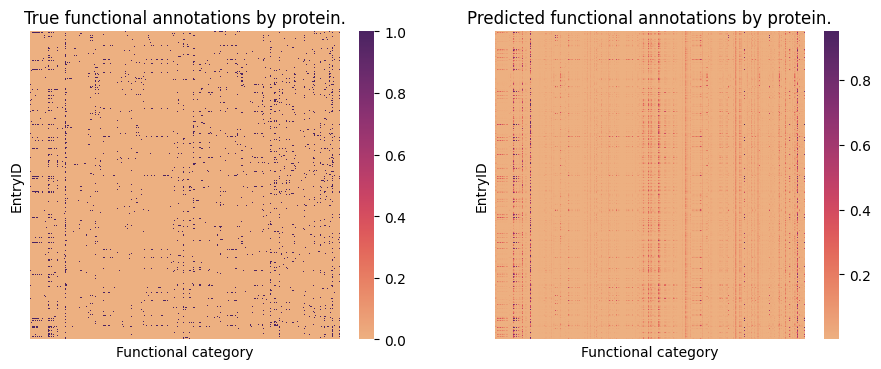

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (11, 4))

sns.heatmap(
    ax = ax[0],
    data = valid_true_df,
    yticklabels = False,
    xticklabels = False,
    cmap = "flare",
)
ax[0].set_title("True functional annotations by protein.")
ax[0].set_xlabel("Functional category")

sns.heatmap(
    ax = ax[1],
    data = valid_prob_df,
    yticklabels = False,
    xticklabels = False,
    cmap = "flare",
)
ax[1].set_title("Predicted functional annotations by protein.")
ax[1].set_xlabel("Functional category")

Some protein functions appear frequently in dataset (vertical stripes) and model predicts these well (left columns).

Rare functions are harder to capture, model often misses them entirely. Some functions are over predicted (faint vertical lines on right) --> model is over-confident for these

### Now evaluate model performance on each protein function individually:


In [ ]:
valid_true_df.head()

,GO:0000166,GO:0000287,GO:0000976,GO:0000977,GO:0000978,GO:0000981,GO:0000987,GO:0001067,GO:0001216,GO:0001217,...,GO:0140677,GO:0140678,GO:1901265,GO:1901363,GO:1901681,GO:1901702,GO:1901981,GO:1902936,GO:1990782,GO:1990837
EntryID,,,,,,,,,,,,,,,,,,,,,
A1A4Y4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
A5LHX3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A5PLL7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A6NHX0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A6NJ46,0,0,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,0,1


In [ ]:
!sed -i 's/\.item()//g' /content/dlfb-clone/src/dlfb/proteins/train.py

#Then reimport compute_metrics

In [ ]:
from dlfb.proteins.train import compute_metrics

In [ ]:
from sklearn import metrics

def compute_metrics(
  targets: np.ndarray, probs: np.ndarray, thresh=0.5
) -> dict[str, float]:
  """Compute accuracy, recall, precision, auPRC, and auROC."""
  if np.sum(targets) == 0:
    return {
      m: 0.0 for m in ["accuracy", "recall", "precision", "auprc", "auroc"]
    }
  return {
    "accuracy": metrics.accuracy_score(targets, probs >= thresh),
    "recall": float(metrics.recall_score(targets, probs >= thresh)),
    "precision": float(metrics.precision_score(
      targets,
      probs >= thresh,
      zero_division=0.0,
    )),
    "auprc": float(metrics.average_precision_score(targets, probs)),
    "auroc": float(metrics.roc_auc_score(targets, probs)),
  }

In [ ]:
metrics_by_function = {}
for function in targets:
  metrics_by_function[function] = compute_metrics(
    valid_true_df[function].values, valid_prob_df[function].values
  )

overview_valid = (
  pd.DataFrame(metrics_by_function)
  .T.merge(go_term_descriptions, left_index=True, right_on="term")
  .set_index("term")
  .sort_values("auprc", ascending=False)
)
print(pd.DataFrame(overview_valid))

            accuracy    recall  precision     auprc     auroc  \
term                                                            
GO:0004930  0.958858  0.000000   0.000000  0.948591  0.982272   
GO:0004888  0.945424  0.177215   1.000000  0.849885  0.968354   
GO:0003824  0.848027  0.731591   0.819149  0.849362  0.909372   
GO:1990837  0.954660  0.543689   0.888889  0.825313  0.970820   
GO:0043565  0.955500  0.649123   0.850575  0.821888  0.963243   
...              ...       ...        ...       ...       ...   
GO:0004714  0.999160  0.000000   0.000000  0.001094  0.232773   
GO:0042626  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:0051015  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:0003774  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:1902936  0.000000  0.000000   0.000000  0.000000  0.000000   

                                                  description  
term                                                           
GO:0004930                

*** Lots of variation in model's performance across protein functions. Performs well on GPCR, but struggles with cytoskeletal motor activity

auPRC and auROC are threshold independent (they assess how well model ranks positive examples above negative across all possible thresholds). In some cases, AUs might be high while precision and recall are low (model assigns higher probabilities to correct labels but these probabilities never exceed the decision threshold).

Closer looks at how often a protein function appears in training data and how well the model learns to predict it in validation set:

In [ ]:
overview_valid = overview_valid.merge(
    pd.DataFrame(train_df[targets].sum(), columns = ["train_n"]),
    left_index = True,
    right_index = True
)

overview_valid.head()

,accuracy,recall,precision,auprc,auroc,description,train_n
GO:0004930,0.958858,0.000000,0.000000,0.948591,0.982272,G protein-coupled receptor activity,138
GO:0004888,0.945424,0.177215,1.000000,0.849885,0.968354,transmembrane signaling receptor activity,228
GO:0003824,0.848027,0.731591,0.819149,0.849362,0.909372,catalytic activity,1210
GO:1990837,0.954660,0.543689,0.888889,0.825313,0.970820,sequence-specific double-stranded DNA binding,321
GO:0043565,0.955500,0.649123,0.850575,0.821888,0.963243,sequence-specific DNA binding,341


Text(0, 0.5, 'Validation auPRC')

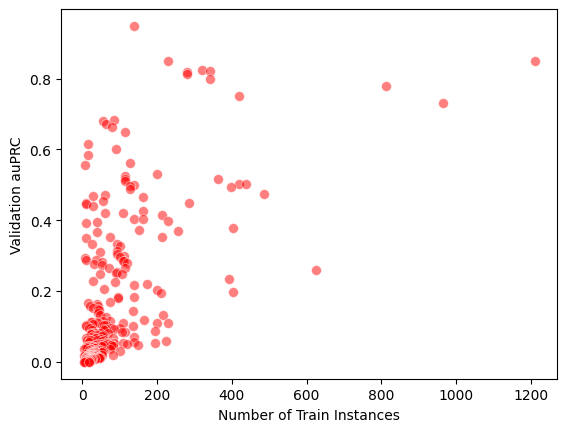

In [ ]:
fig = sns.scatterplot(
    x = "train_n", y = "auprc", data = overview_valid, alpha = 0.5, s = 50, color = "red"
)
fig.set_xlabel("Number of Train Instances")
fig.set_ylabel("Validation auPRC")

Protein functions that occur more frequently in the training set tend to be predicted more accurately by the model on the validation set (measured by auPRC)

# EVALUATION OF MODEL'S USEFULNESS


Compare model against two simple baselines: coin flip (for each protein function, randomly predict 0/1 with equal probability, total ignorange)

Proportional guessing: predict 1 for each function with prob. equal to its frequency in training set (prior class distribution knowledge but no learning)

In [ ]:
def make_coin_flip_predictions(
  valid_true_df: pd.DataFrame, targets: list[str]
) -> pd.DataFrame:
  """Make random coin flip predictions for each protein function."""
  predictions = np.random.choice([0.0, 1.0], size=valid_true_df.shape)
  return pd.DataFrame(predictions, columns=targets, index=valid_true_df.index)


def make_proportional_predictions(
  valid_true_df: pd.DataFrame, train_df: pd.DataFrame, targets: list[str]
) -> pd.DataFrame:
  """Make random protein function predictions proportional to frequency."""
  percent_1_train = dict(train_df[targets].mean())
  proportional_preds = []
  for target_column in targets:
    prob_1 = percent_1_train[target_column]
    prob_0 = 1 - prob_1
    proportional_preds.append(
      np.random.choice([0.0, 1.0], size=len(valid_true_df), p=[prob_0, prob_1])
    )
  return pd.DataFrame(
    np.stack(proportional_preds).T, columns=targets, index=valid_true_df.index
  )

In [ ]:
prediction_methods = {
    "coin_flip_baseline" : make_coin_flip_predictions(valid_true_df, targets),
    "proportional_guess_baseline" : make_proportional_predictions(valid_true_df, train_df, targets),
    "model" : valid_prob_df
}

In [ ]:
prediction_methods

{'coin_flip_baseline':          GO:0000166  GO:0000287  GO:0000976  GO:0000977  GO:0000978  \
 EntryID                                                               
 A1A4Y4          1.0         0.0         0.0         0.0         0.0   
 A5LHX3          0.0         1.0         1.0         1.0         1.0   
 A5PLL7          0.0         0.0         1.0         0.0         1.0   
 A6NHX0          0.0         0.0         0.0         0.0         1.0   
 A6NJ46          1.0         1.0         1.0         0.0         0.0   
 ...             ...         ...         ...         ...         ...   
 Q9Y6J6          1.0         0.0         1.0         0.0         1.0   
 Q9Y6K0          0.0         0.0         0.0         0.0         0.0   
 Q9Y6K9          0.0         0.0         0.0         1.0         0.0   
 Q9Y6V7          0.0         0.0         0.0         1.0         0.0   
 Q9Y6Z7          1.0         0.0         0.0         0.0         1.0   
 
          GO:0000981  GO:0000987  GO:000

Now compute per-protein metrics and average them:

In [ ]:
metrics_by_method = {}
for method, preds_df in prediction_methods.items():
  metrics_by_method[method] = pd.DataFrame(
      [
          compute_metrics(valid_true_df.iloc[i], preds_df.iloc[i])
          for i in range(len(valid_true_df))
      ]
  ).mean()

pd.DataFrame(metrics_by_method).head()

,coin_flip_baseline,proportional_guess_baseline,model
accuracy,0.500833,0.957076,0.978569
recall,0.507493,0.091118,0.128532
precision,0.023781,0.085290,0.424301
auprc,0.025235,0.040018,0.412350
auroc,0.504155,0.534700,0.882679


Now break down model's strengths and weaknesses by individual protein function and compare perofrmance against both baselines

In [ ]:
auprc_by_function = {}

for method, preds_df in prediction_methods.items():
  metrics_by_function = {}

  for function in targets:
    metrics_by_function[function] = compute_metrics(
      valid_true_df[function], preds_df[function]
    )

  auprc_by_function[method] = (
      pd.DataFrame(metrics_by_function)
      .T.merge(go_term_descriptions, left_index=True, right_on="term")
      .set_index("term")
      .sort_values("auprc", ascending=False)
  )["auprc"].to_dict()

In [ ]:
auprc_by_function

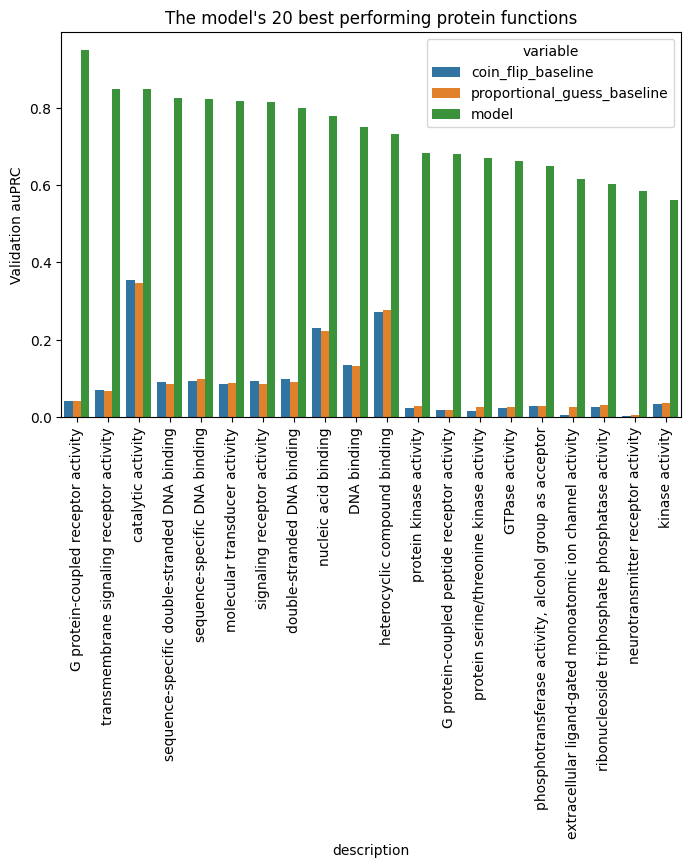

In [ ]:
best_performing = (
  pd.DataFrame(auprc_by_function)
  .merge(go_term_descriptions, left_index=True, right_on="term")
  .set_index("term")
  .sort_values("model", ascending=False)
  .head(20)
  .melt("description")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
  x="description",
  y="value",
  hue="variable",
  data=best_performing,
)
ax.set_title("The model's 20 best performing protein functions")
ax.set_ylabel("Validation auPRC")
plt.xticks(rotation=90);

In [ ]:
best_performing.head()

,description,variable,value
0,G protein-coupled receptor activity,coin_flip_baseline,0.041051
1,transmembrane signaling receptor activity,coin_flip_baseline,0.069760
2,catalytic activity,coin_flip_baseline,0.353894
3,sequence-specific double-stranded DNA binding,coin_flip_baseline,0.091114
4,sequence-specific DNA binding,coin_flip_baseline,0.094050


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'G protein-coupled receptor activity'),
  Text(1, 0, 'transmembrane signaling receptor activity'),
  Text(2, 0, 'catalytic activity'),
  Text(3, 0, 'sequence-specific double-stranded DNA binding'),
  Text(4, 0, 'sequence-specific DNA binding'),
  Text(5, 0, 'molecular transducer activity'),
  Text(6, 0, 'signaling receptor activity'),
  Text(7, 0, 'double-stranded DNA binding'),
  Text(8, 0, 'nucleic acid binding'),
  Text(9, 0, 'DNA binding'),
  Text(10, 0, 'heterocyclic compound binding'),
  Text(11, 0, 'protein kinase activity'),
  Text(12, 0, 'G protein-coupled peptide receptor activity'),
  Text(13, 0, 'protein serine/threonine kinase activity'),
  Text(14, 0, 'GTPase activity'),
  Text(15, 0, 'phosphotransferase activity, alcohol group as acceptor'),
  Text(16, 0, 'extracellular ligand-gated monoatomic ion channel activity'),
  Text(17, 0, 'ribonucleoside triphosphate phosphatase activity'),
  T

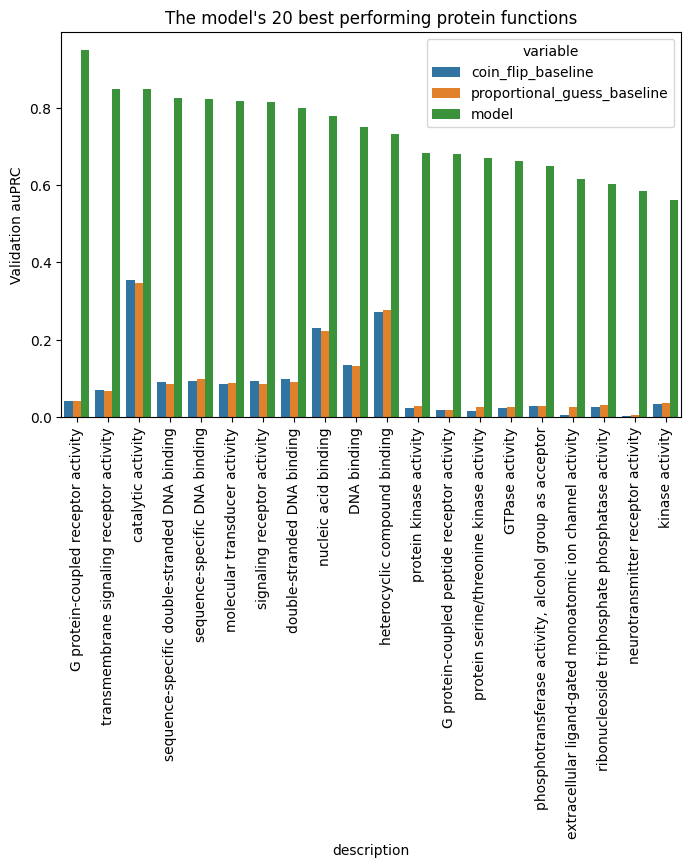

In [ ]:
fig, ax = plt.subplots(figsize = (8,5))
sns.barplot(
    x = "description",
    y = "value",
    data = best_performing,
    hue = "variable"
)
ax.set_title("The model's 20 best performing protein functions")
ax.set_ylabel("Validation auPRC")
plt.xticks(rotation = 90)

### BIOLOGICAL AND ANALYTICAL EXPLORATION:

Optimize threshold to address high auPRC but low recall, also use F1 score metrics

Species generalization, function-specific performance drivers (why model performs well on some functions but poorly on others), examine protein multifunctionality (does model struggle more on proteins with many functions), false postives that might be real?


### ML IMPROVEMENTS:
Tune the MLP (add more layers, dropouts, batch normalization)

Alternative input encodings: attention pooling or a small 1D CNN or transformers on top of the token-level embeddings

Further feature engineering, predict funtion hierarchically, alternative base models, unfreeze the language model